<a href="https://colab.research.google.com/github/D2718281828nis/ML-TimeSeries_Forecasting_Ensemble/blob/master/example-GCN-DTW-timeseries-forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ---Cell 1: Setup and Imports---

In [23]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.spatial.distance import pdist, squareform
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(37)
torch.manual_seed(37)


# Install necessary packages if not already available
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")
print(f"Using PyTorch version: {torch.__version__}")
print(f"Using NetworkX version: {nx.__version__}")

Libraries imported successfully.
Using PyTorch version: 2.11.0+cpu
Using NetworkX version: 3.6.1


# ---Cell 2: Synthetic Data Generation---

In [24]:
def generate_synthetic_multivariate_ts(n_series=10, n_steps=100, n_features=1):
    # Generate a base trend that introduces correlation
    base_trend = np.sin(np.linspace(0, 4 * np.pi, n_steps))
    # Add some noise to the base trend for variation
    series_data = []
    for i in range(n_series):
        # Each series is a combination of the base trend and its own noise/random walk
        # This creates correlation between series
        individual_noise = np.random.normal(0, 0.1, n_steps)
        series_i = base_trend + np.cumsum(individual_noise) * 0.5 + np.random.normal(0, 0.05, n_steps)
        series_data.append(series_i)
    # Stack series into shape (n_steps, n_series)
    ts_data = np.column_stack(series_data)
    return ts_data

# Parameters for synthetic data
N_SERIES = 5  # Number of time series
N_STEPS = 200 # Total number of time steps
SEQ_LEN = 10  # Length of input sequence
PRED_LEN = 1  # Length of prediction (forecast horizon)

# Generate the dataset
raw_data = generate_synthetic_multivariate_ts(N_SERIES, N_STEPS, 1)
print(f"Generated data shape: {raw_data.shape}") # Expected: (200, 5)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(raw_data)

# Create sequences for supervised learning
def create_sequences(data, seq_len, pred_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        x = data[i:(i + seq_len)]
        y = data[(i + seq_len):(i + seq_len + pred_len)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, SEQ_LEN, PRED_LEN)
print(f"Sequences X shape: {X.shape}") # Expected: (190, 10, 5)
print(f"Sequences y shape: {y.shape}") # Expected: (190, 1, 5)

# Split data into train and test sets
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train X shape: {X_train.shape}, Test X shape: {X_test.shape}")
print(f"Train y shape: {y_train.shape}, Test y shape: {y_test.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

Generated data shape: (200, 5)
Sequences X shape: (190, 10, 5)
Sequences y shape: (190, 1, 5)
Train X shape: (152, 10, 5), Test X shape: (38, 10, 5)
Train y shape: (152, 1, 5), Test y shape: (38, 1, 5)



# ---Cell 3: Visualization of Generated Data and Graph Structure---

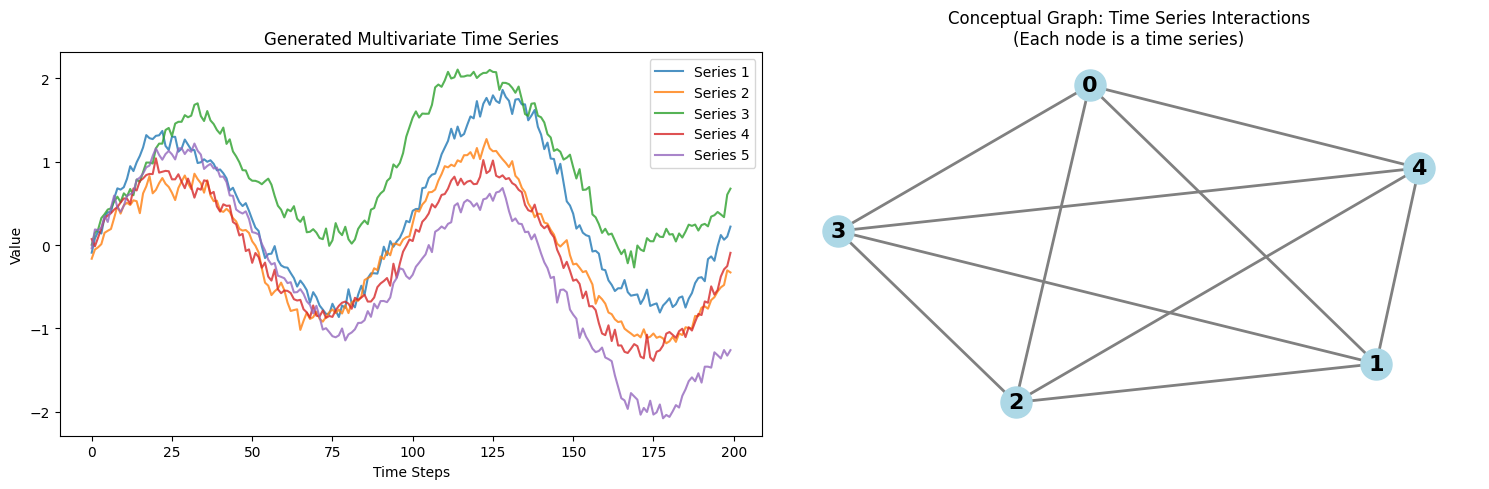

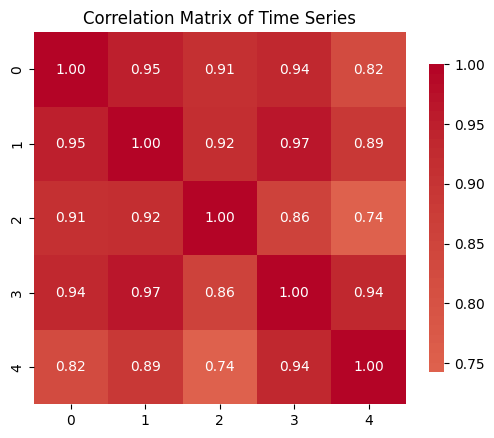

In [26]:
plt.figure(figsize=(15, 5))

# Plot raw time series data
plt.subplot(1, 2, 1)
for i in range(N_SERIES):
    plt.plot(raw_data[:, i], label=f'Series {i+1}', alpha=0.8)
plt.title('Generated Multivariate Time Series')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()

# Visualize the conceptual graph structure representing series correlations
plt.subplot(1, 2, 2)
G_conceptual = nx.complete_graph(N_SERIES)
pos = nx.spring_layout(G_conceptual, seed=42)
nx.draw(G_conceptual, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_size=16, font_weight='bold',
        edge_color='gray', width=2)
plt.title('Conceptual Graph: Time Series Interactions\n(Each node is a time series)')
plt.tight_layout()
plt.show()

# Calculate correlation matrix to visualize relationships
corr_matrix = np.corrcoef(raw_data.T)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Time Series')
plt.show()


# ---Cell 4: Define Model Architectures---


In [27]:
class RNN_IMP(nn.Module):
    """RNN with Implicit Graph Structure (standard RNN, no explicit graph)"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super(RNN_IMP, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Using GRU as per the paper's description of RNN+IMP using GRU
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        out, _ = self.rnn(x) # out shape: (batch, seq_len, hidden_size)
        # Take the output from the last time step
        out = self.fc(out[:, -1, :]) # Shape: (batch, output_size)
        # Reshape to match expected output: (batch, pred_len, n_nodes)
        return out.unsqueeze(1)

class RNN_AMP(nn.Module):
    """RNN with Attention Mechanism (Attention-based Message Passing)"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super(RNN_AMP, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Using GRU as per the paper's description of RNN+AMP using GRU
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        # Attention mechanism: computes weights for each time step
        self.attention = nn.Linear(hidden_size, 1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        out, _ = self.rnn(x) # out shape: (batch, seq_len, hidden_size)
        # Compute attention weights for each time step
        attn_weights = torch.softmax(torch.squeeze(self.attention(out), dim=-1), dim=-1) # Shape: (batch, seq_len)
        # Apply attention weights
        context_vector = torch.bmm(attn_weights.unsqueeze(1), out).squeeze(1) # Shape: (batch, hidden_size)
        out = self.fc(context_vector) # Shape: (batch, output_size)
        return out.unsqueeze(1) # Shape: (batch, pred_len, n_nodes)

class GraphConvLayer(nn.Module):
    """Simple Graph Convolution Layer (based on basic GCN idea)"""
    def __init__(self, in_features, out_features):
        super(GraphConvLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj_matrix):
        # x shape: (batch, n_nodes, features)
        # adj_matrix shape: (n_nodes, n_nodes)
        # Normalize adjacency matrix (D^{-1/2} A D^{-1/2}) - simplified here
        # For simplicity, we'll just multiply A * X * W
        # A more rigorous normalization would involve degree matrix D
        ax = torch.matmul(adj_matrix, x) # Shape: (batch, n_nodes, features)
        output = self.linear(ax) # Shape: (batch, n_nodes, out_features)
        return output

class GCRNN_IMP(nn.Module):
    """Graph Convolutional RNN with Implicit Graph Structure (static/dynamic adjacency)"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, n_nodes, dropout=0.1):
        super(GCRNN_IMP, self).__init__()
        self.hidden_size = hidden_size
        self.n_nodes = n_nodes
        self.output_size = output_size

        # Learnable adjacency matrix (initially based on correlation)
        self.adjacency = nn.Parameter(torch.randn(n_nodes, n_nodes) * 0.01)

        # Graph convolution layer processes node features with adjacency info
        self.graph_conv = GraphConvLayer(1, hidden_size) # Changed input_size to 1

        # The RNN now operates on the *graph-processed* features for each node
        # Since the graph conv output for each node is `hidden_size`, the RNN takes that as input
        # Paper suggests a "gated GCRNN", using GRU-like cells as described in equations 15-19
        # For simplicity, we use a standard GRU here, but it operates on the graph-enhanced features
        self.rnn = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        # The final layer maps the RNN's hidden state back to the desired output size (per node)
        # It should predict 1 value per node, not output_size (N_SERIES) values per node.
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, n_nodes) - Each sample is a sequence of snapshots of the graph
        batch_size, seq_len, n_nodes = x.size()

        # We need to process the graph structure at each time step
        # The input x represents the state of n_nodes nodes at each of seq_len time steps
        # Shape after unsqueeze: (batch, seq_len, n_nodes, 1) - treating each node's value as a 1D feature
        x_expanded = x.unsqueeze(-1) # Shape: (batch, seq_len, n_nodes, 1)

        # Pre-allocate tensor to store graph-convolved sequences for each node
        # This will hold the sequence of enhanced features for each node over time
        # Shape: (batch, seq_len, n_nodes, hidden_size)
        gc_seq_all_nodes = torch.zeros(batch_size, seq_len, n_nodes, self.hidden_size, device=x.device)

        # Process each time step through graph convolution
        for t in range(seq_len):
            # x_at_time_t: (batch, n_nodes, 1)
            x_at_time_t = x_expanded[:, t, :, :]
            # Apply graph convolution: (batch, n_nodes, hidden_size)
            gc_out_at_t = self.graph_conv(x_at_time_t, self.adjacency)
            # Store in the sequence tensor: (batch, n_nodes, hidden_size)
            gc_seq_all_nodes[:, t, :, :] = gc_out_at_t

        # Now, for each node, we have its sequence of graph-convolved features
        # Shape of gc_seq_all_nodes is (batch, seq_len, n_nodes, hidden_size)
        # We want to pass the sequence for each node through the RNN individually
        # Resulting in an RNN output for each node
        # Transpose to get (batch, n_nodes, seq_len, hidden_size) so we can iterate over nodes
        gc_seq_by_node = gc_seq_all_nodes.transpose(1, 2) # Shape: (batch, n_nodes, seq_len, hidden_size)

        # Pre-allocate tensor for final outputs for all nodes
        # Shape: (batch, n_nodes) as we predict 1 value per node
        final_node_outputs = torch.zeros(batch_size, n_nodes, device=x.device)

        # Iterate through each node and process its sequence
        for i in range(self.n_nodes):
            # Extract the sequence for node i: (batch, seq_len, hidden_size)
            node_i_seq = gc_seq_by_node[:, i, :, :] # Shape: (batch, seq_len, hidden_size)
            # Pass the sequence through the RNN: (batch, seq_len, hidden_size)
            rnn_out, _ = self.rnn(node_i_seq)
            # Take the output from the *last* time step of the RNN for this node: (batch, hidden_size)
            # This represents the node's state after processing its entire sequence with graph context
            last_output_for_node_i = rnn_out[:, -1, :]
            # Pass through final linear layer to get the prediction for this node: (batch, 1)
            node_i_pred = self.fc(last_output_for_node_i)
            # Store the prediction for this node in the final output tensor
            final_node_outputs[:, i] = node_i_pred.squeeze(-1) # Assign (batch,) to (batch,)

        # Return shape: (batch, pred_len, n_nodes) -> (batch, 1, n_nodes) for pred_len=1
        return final_node_outputs.unsqueeze(1)

class GCRNN_AMP(nn.Module):
    """Graph Convolutional RNN with Attention-based Message Passing)"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, n_nodes, dropout=0.1):
        super(GCRNN_AMP, self).__init__()
        self.hidden_size = hidden_size
        self.n_nodes = n_nodes
        self.output_size = output_size

        # Learnable adjacency matrix
        self.adjacency = nn.Parameter(torch.randn(n_nodes, n_nodes) * 0.01)

        # Graph convolution layer
        self.graph_conv = GraphConvLayer(1, hidden_size) # Changed input_size to 1

        # RNN to process graph-convolved sequences for each node
        self.rnn = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        # Attention layer for inter-node messages (anisotropic message passing)
        # This learns attention weights for each node based on its neighbors' states
        # As per paper, this implements anisotropic message passing (equations 9-10)
        self.msg_attention_src = nn.Linear(hidden_size, hidden_size // 2) # For source node
        self.msg_attention_tgt = nn.Linear(hidden_size, hidden_size // 2) # For target node
        self.msg_attention_out = nn.Linear(hidden_size // 2, 1) # Final attention weight

        # It should predict 1 value per node, not output_size (N_SERIES) values per node.
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, n_nodes)
        batch_size, seq_len, n_nodes = x.size()

        # Expand input to include feature dimension
        x_expanded = x.unsqueeze(-1) # Shape: (batch_size, seq_len, n_nodes, 1)

        # Pre-allocate tensor for graph-convolved sequences
        gc_seq_all_nodes = torch.zeros(batch_size, seq_len, n_nodes, self.hidden_size, device=x.device)

        # Process each time step through graph convolution
        for t in range(seq_len):
            x_at_time_t = x_expanded[:, t, :, :] # Shape: (batch, n_nodes, 1)
            gc_out_at_t = self.graph_conv(x_at_time_t, self.adjacency) # Shape: (batch, n_nodes, hidden_size)
            gc_seq_all_nodes[:, t, :, :] = gc_out_at_t

        # Process each node's sequence through RNN with attention
        gc_seq_by_node = gc_seq_all_nodes.transpose(1, 2) # Shape: (batch, n_nodes, seq_len, hidden_size)

        # Pre-allocate tensor for final outputs for all nodes
        # Shape: (batch, n_nodes) as we predict 1 value per node
        final_outputs = torch.zeros(batch_size, n_nodes, device=x.device)

        for i in range(self.n_nodes):
            # Get the sequence for node i: (batch, seq_len, hidden_size)
            node_seq = gc_seq_by_node[:, i, :, :] # Shape: (batch, seq_len, hidden_size)

            # To implement attention, we need to aggregate messages from neighbors
            # For each time step in the sequence, calculate attention-weighted messages
            # This is the anisotropic message passing (AMP) part
            # Following the paper's description, this involves computing attention based on node states
            rnn_inputs = []
            for t_idx in range(seq_len):
                h_current = node_seq[:, t_idx, :] # (batch, hidden_size) - state of node i at time t
                # Get all neighbor states at this time step: (batch, n_nodes, hidden_size)
                h_neighbors = gc_seq_by_node[:, :, t_idx, :]

                # Calculate attention scores for messages from each neighbor to node i
                # Anisotropic: attention depends on both source and target node states
                # Calculate features for source (neighbor) and target (current node) nodes
                h_src_proj = self.msg_attention_src(h_neighbors) # (batch, n_nodes, hidden_size//2)
                h_tgt_proj = self.msg_attention_tgt(h_current).unsqueeze(1) # (batch, 1, hidden_size//2)

                # Combine source and target projections
                h_combined = torch.tanh(h_src_proj + h_tgt_proj) # Broadcasting: (batch, n_nodes, hidden_size//2)

                # Calculate attention weights: (batch, n_nodes, 1)
                attn_logits = self.msg_attention_out(h_combined)
                attn_weights = torch.softmax(attn_logits, dim=1) # Softmax over neighbors

                # Weighted sum of neighbor states: (batch, hidden_size)
                aggregated_message = torch.sum(attn_weights * h_neighbors, dim=1)

                # The RNN input for node i at time t is the aggregated message
                # This is the core of AMP: the message passed to the RNN is weighted by attention
                rnn_input_t = aggregated_message
                rnn_inputs.append(rnn_input_t)

            # Stack inputs for the RNN: (batch, seq_len, hidden_size)
            stacked_inputs = torch.stack(rnn_inputs, dim=1)

            # Pass through RNN: (batch, seq_len, hidden_size)
            rnn_out, _ = self.rnn(stacked_inputs)
            # Take the output from the last time step: (batch, hidden_size)
            node_pred_raw = rnn_out[:, -1, :]

            # Final prediction for this node: (batch, 1)
            node_pred = self.fc(node_pred_raw)

            # Store in final output tensor
            final_outputs[:, i] = node_pred.squeeze(-1) # Assign (batch,) to (batch,)

        # Return shape: (batch, pred_len, n_nodes) -> (batch, 1, n_nodes) for pred_len=1
        return final_outputs.unsqueeze(1)

# ---Cell 5: Model Training Function---


In [28]:


def train_model(model, train_loader, criterion, optimizer, num_epochs=50, device='cpu'):
    model.train()
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses


# ---Cell 6: Initialize Models and Prepare Data Loaders---


In [29]:

# Define model parameters based on paper's hyperparameters
INPUT_SIZE = N_SERIES  # Features per time step (number of series)
HIDDEN_SIZE = 32 # As specified in the paper
NUM_LAYERS = 1 # As specified in the paper for GCRNNs
OUTPUT_SIZE = N_SERIES # Predict one value for each series
N_NODES = N_SERIES

# Instantiate models
model_rnn_imp = RNN_IMP(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
model_rnn_amp = RNN_AMP(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
model_gcnn_imp = GCRNN_IMP(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, N_NODES)
model_gcnn_amp = GCRNN_AMP(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, N_NODES)

# Prepare data loaders
BATCH_SIZE = 32 # As specified in the paper (or 128 for GPVAR)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models = {
    'RNN_IMP': model_rnn_imp,
    'RNN_AMP': model_rnn_amp,
    'GCRNN_IMP': model_gcnn_imp,
    'GCRNN_AMP': model_gcnn_amp
}

# Move models to device
for name, model in models.items():
    model.to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()

# Learning rate as specified in the paper (0.003, halved every 50 epochs)
LEARNING_RATE = 0.003
optimizers = {name: optim.Adam(model.parameters(), lr=LEARNING_RATE) for name, model in models.items()}


Using device: cpu


# ---Cell 7: Train Models and Collect Metrics---

In [30]:

print("--- Starting Model Training ---")
all_losses = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    optimizer = optimizers[name]
    losses = train_model(model, train_loader, criterion, optimizer, num_epochs=50, device=device)
    all_losses[name] = losses

    # Make predictions on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor.to(device))
        predictions[name] = test_outputs.cpu().numpy()

print("\n--- Training Complete ---")

--- Starting Model Training ---

Training RNN_IMP...
Epoch [10/50], Loss: 0.0584
Epoch [20/50], Loss: 0.0239
Epoch [30/50], Loss: 0.0168
Epoch [40/50], Loss: 0.0122
Epoch [50/50], Loss: 0.0108

Training RNN_AMP...
Epoch [10/50], Loss: 0.1431
Epoch [20/50], Loss: 0.0266
Epoch [30/50], Loss: 0.0189
Epoch [40/50], Loss: 0.0153
Epoch [50/50], Loss: 0.0137

Training GCRNN_IMP...
Epoch [10/50], Loss: 0.0659
Epoch [20/50], Loss: 0.0272
Epoch [30/50], Loss: 0.0169
Epoch [40/50], Loss: 0.0136
Epoch [50/50], Loss: 0.0125

Training GCRNN_AMP...
Epoch [10/50], Loss: 0.0967
Epoch [20/50], Loss: 0.0898
Epoch [30/50], Loss: 0.0870
Epoch [40/50], Loss: 0.0876
Epoch [50/50], Loss: 0.0876

--- Training Complete ---


# ---Cell 8: Evaluate Models---


In [31]:


def evaluate_predictions(y_true, y_pred, model_name):
    """Calculate evaluation metrics."""
    # y_true and y_pred are shape (batch, pred_len, n_nodes)
    # Flatten for metric calculation
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)

    print(f"{model_name}: MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")
    return mse, mae, rmse

eval_metrics = {}
for name, pred in predictions.items():
    eval_metrics[name] = evaluate_predictions(y_test, pred, name)

RNN_IMP: MSE=0.0517, MAE=0.1852, RMSE=0.2273
RNN_AMP: MSE=0.1182, MAE=0.2809, RMSE=0.3438
GCRNN_IMP: MSE=0.0192, MAE=0.1075, RMSE=0.1386
GCRNN_AMP: MSE=0.0511, MAE=0.1846, RMSE=0.2260


# ---Cell 9: Plot Training Losses---

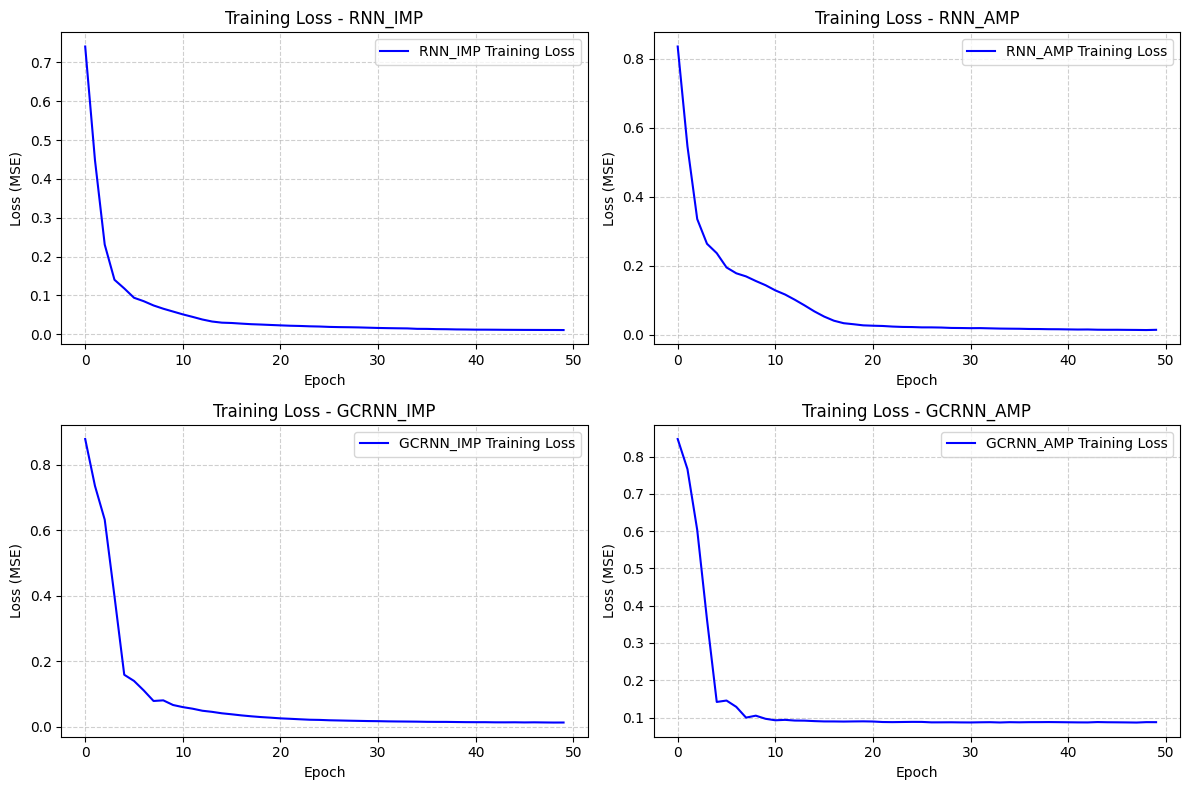


Visualizing predictions for best model: GCRNN_IMP


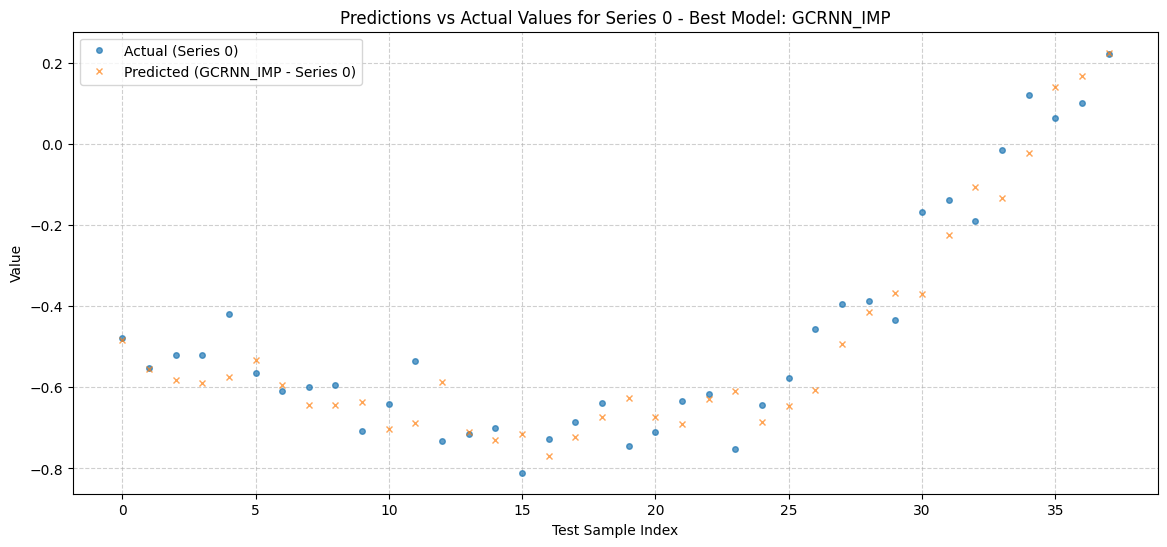


--- Model Performance Summary (Ranked by RMSE) ---
                MSE       MAE      RMSE  Rank (by RMSE)
GCRNN_IMP  0.019217  0.107543  0.138624               1
GCRNN_AMP  0.051094  0.184563  0.226039               2
RNN_IMP    0.051651  0.185169  0.227269               3
RNN_AMP    0.118177  0.280889  0.343768               4


In [33]:


plt.figure(figsize=(12, 8))
for i, (name, losses) in enumerate(all_losses.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(losses, label=f'{name} Training Loss', color='blue')
    plt.title(f'Training Loss - {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
plt.tight_layout()
plt.show()

best_model_name = min(eval_metrics, key=lambda k: eval_metrics[k][2]) # Choose model with lowest RMSE
print(f"\nVisualizing predictions for best model: {best_model_name}")
best_pred = predictions[best_model_name]

# Inverse transform all scaled values back to original scale first
# Reshape y_test and best_pred to (num_samples * pred_len, N_SERIES) for inverse_transform
y_test_reshaped = y_test.reshape(-1, N_SERIES)
best_pred_reshaped = best_pred.reshape(-1, N_SERIES)

y_test_unscaled = scaler.inverse_transform(y_test_reshaped).reshape(y_test.shape)
best_pred_unscaled = scaler.inverse_transform(best_pred_reshaped).reshape(best_pred.shape)

# Plot predictions for the first time series (Series 0) over all test samples
test_indices = range(len(best_pred_unscaled))
actual_values_series_0 = y_test_unscaled[:, 0, 0]  # True values for series 0, first prediction step, first series
pred_values_series_0 = best_pred_unscaled[:, 0, 0]  # Predicted values for series 0, first prediction step, first series

plt.figure(figsize=(14, 6))
plt.plot(test_indices, actual_values_series_0, label='Actual (Series 0)', marker='o', linestyle='', markersize=4, alpha=0.7)
plt.plot(test_indices, pred_values_series_0, label=f'Predicted ({best_model_name} - Series 0)', marker='x', linestyle='', markersize=4, alpha=0.7)
plt.title(f'Predictions vs Actual Values for Series 0 - Best Model: {best_model_name}')
plt.xlabel('Test Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

summary_df = pd.DataFrame.from_dict(eval_metrics, orient='index', columns=['MSE', 'MAE', 'RMSE'])
summary_df['Rank (by RMSE)'] = summary_df['RMSE'].rank(method='min').astype(int)
summary_df_sorted = summary_df.sort_values(by='RMSE')

print("\n--- Model Performance Summary (Ranked by RMSE) ---")
print(summary_df_sorted)

# ---Cell 10: Visualize Graph Structure Learned by GCRNN Models (Example Adjacency Matrices)---


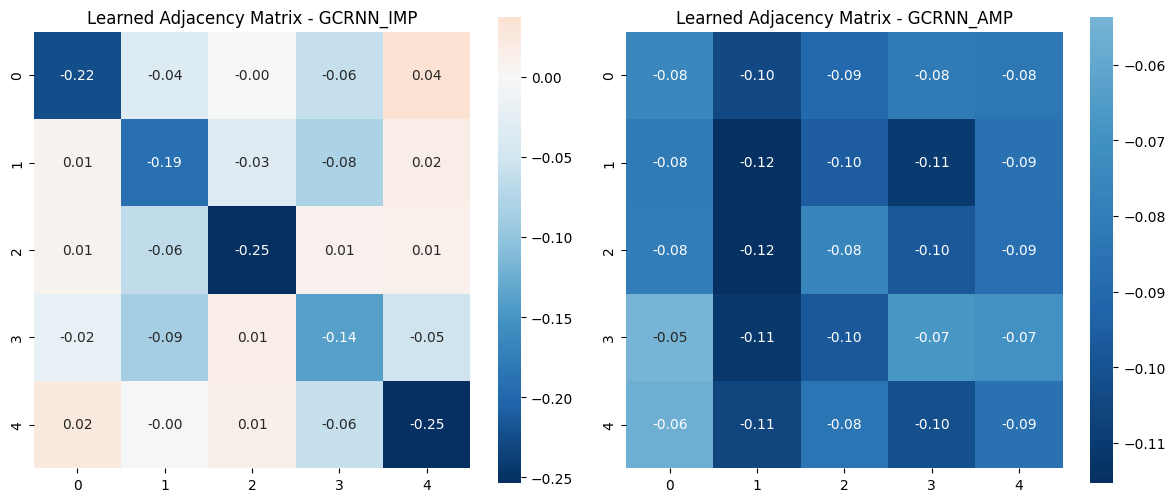


--- Graph Message Passing Example ---
Sample input shape for GCRNN: torch.Size([1, 1, 5])
Input shape for GraphConvLayer: torch.Size([1, 5, 1])
Output of GraphConvLayer shape: torch.Size([1, 5, 32])
First sample's graph convolution output for GCRNN_IMP (first 3 values of first node):
tensor([-0.7028,  0.5528, -1.1720])

This demonstrates how the graph convolution layer processes the node features using the learned adjacency matrix to produce enhanced node representations.


In [34]:
plt.figure(figsize=(12, 5))
for i, name in enumerate(['GCRNN_IMP', 'GCRNN_AMP']):
    model = models[name]
    # Get the learned adjacency matrix parameter
    adj_matrix = model.adjacency.detach().cpu().numpy()
    plt.subplot(1, 2, i+1)
    sns.heatmap(adj_matrix, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f')
    plt.title(f'Learned Adjacency Matrix - {name}')
plt.tight_layout()
plt.show()

# Demonstrate how the adjacency matrix affects message passing
print("\n--- Graph Message Passing Example ---")
sample_input = X_test_tensor[:1, -1:, :] # Shape: (1, 1, n_nodes) - Last time step of first sample
print(f"Sample input shape for GCRNN: {sample_input.shape}")

# Prepare input for graph convolution layer
# graph_conv expects (batch, n_nodes, features) and adj_matrix
# From GCRNN_IMP forward: x_expanded = x.unsqueeze(-1), then x_at_time_t = x_expanded[:, t, :, :]
sample_input_for_gc = sample_input.unsqueeze(-1)[:, 0, :, :] # Shape: (1, n_nodes, 1)
print(f"Input shape for GraphConvLayer: {sample_input_for_gc.shape}")

# Get learned adjacency matrix from GCRNN_IMP (or GCRNN_AMP)
gcrnn_imp_adj = models['GCRNN_IMP'].adjacency.detach()

# Apply graph convolution
with torch.no_grad():
    gc_output = models['GCRNN_IMP'].graph_conv(sample_input_for_gc, gcrnn_imp_adj)

print(f"Output of GraphConvLayer shape: {gc_output.shape}")
print("First sample's graph convolution output for GCRNN_IMP (first 3 values of first node):")
print(gc_output[0, 0, :3])
print("\nThis demonstrates how the graph convolution layer processes the node features using the learned adjacency matrix to produce enhanced node representations.")

---Cell 11: Graph Structure Explained ---

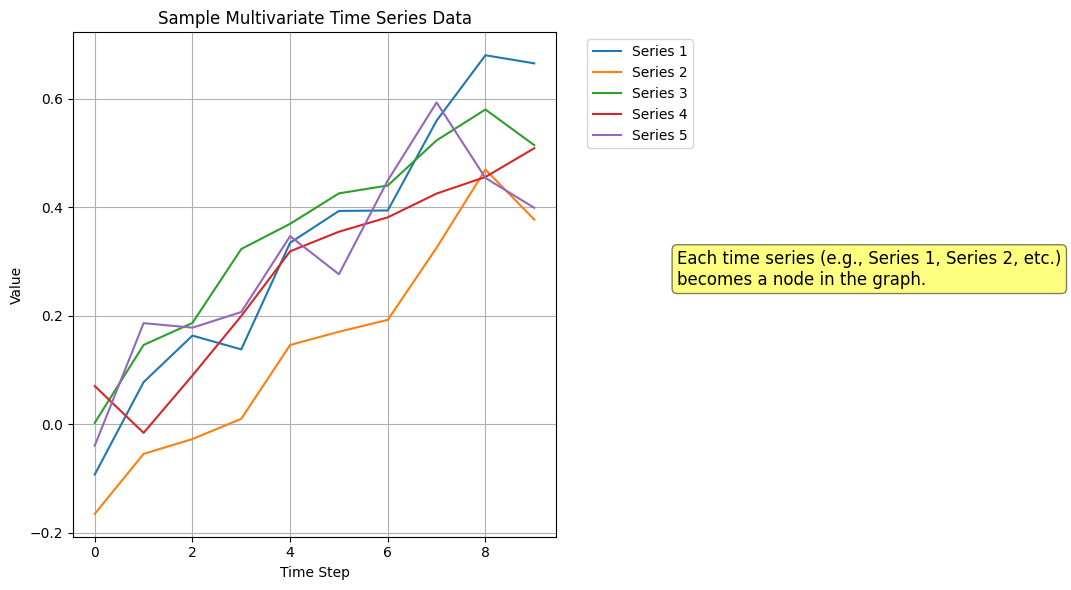

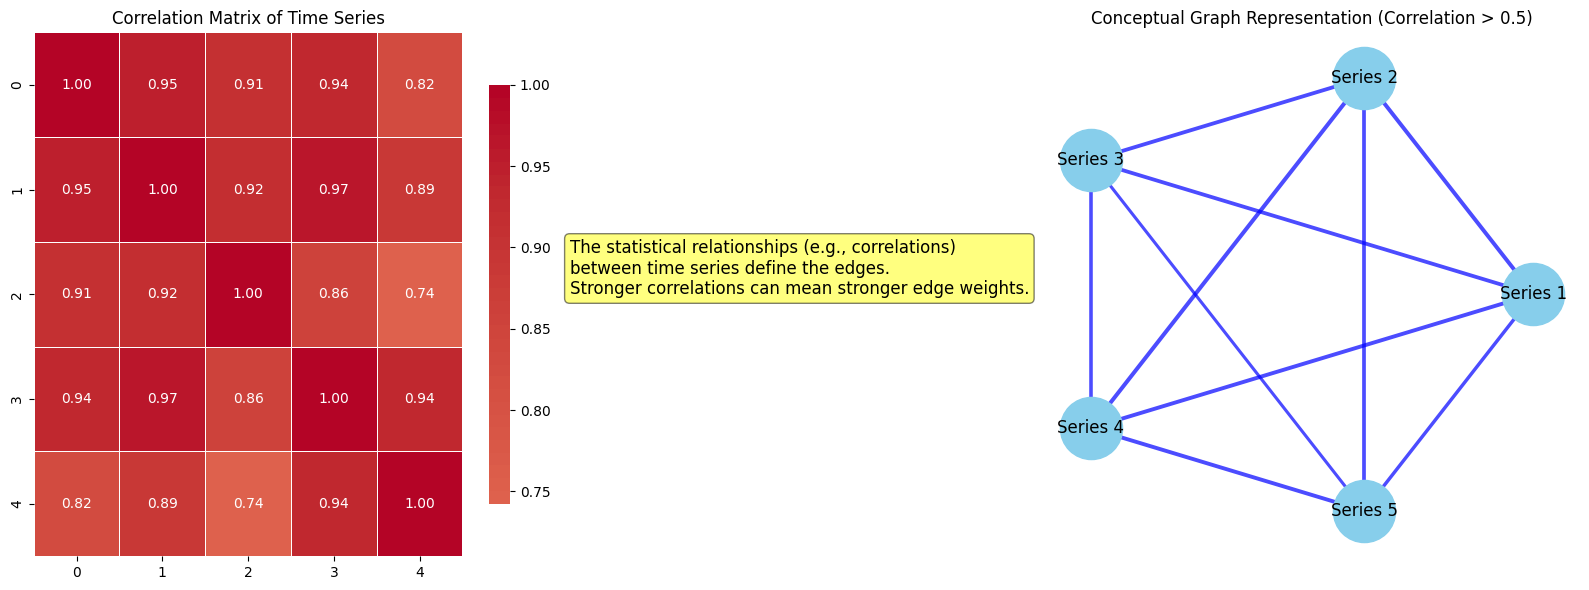

These visualizations demonstrate the conceptual transformation:
1. Each individual time series becomes a node in the graph.
2. The statistical relationships (e.g., correlation) between these time series define the edges and their weights.
This forms the basis for Graph Neural Networks to process time series data while accounting for inter-series dependencies.


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns

# Assuming raw_data and corr_matrix are already defined from previous cells
# Example data if not already run (for standalone demonstration):
# np.random.seed(42)
# N_SERIES_DEMO = 5
# N_STEPS_DEMO = 20
# raw_data_demo = np.random.rand(N_STEPS_DEMO, N_SERIES_DEMO)
# corr_matrix_demo = np.corrcoef(raw_data_demo.T)

# --- Visualization 1: Time Series to Nodes ---
# Using a small segment of the previously generated raw_data
demo_steps = 10
demo_series_count = N_SERIES # Use all series for nodes

sample_ts_data = raw_data[:demo_steps, :demo_series_count]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
for i in range(demo_series_count):
    plt.plot(sample_ts_data[:, i], label=f'Series {i+1}')
plt.title('Sample Multivariate Time Series Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Add text explanation for nodes
plt.text(1.25, 0.5,
         'Each time series (e.g., Series 1, Series 2, etc.)\nbecomes a node in the graph.',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()

# --- Visualization 2: Correlation to Edges and Graph Structure ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt=".2f", linewidths=.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Time Series')

# Add text explanation for edges
plt.text(1.25, 0.5,
         'The statistical relationships (e.g., correlations)\nbetween time series define the edges.\nStronger correlations can mean stronger edge weights.',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

# Create a graph based on correlation
G = nx.Graph()
labels = {i: f'Series {i+1}' for i in range(N_SERIES)}
G.add_nodes_from(labels.keys())

# Add edges based on a threshold of absolute correlation
threshold = 0.5 # Only add edges for correlations above this threshold
for i in range(N_SERIES):
    for j in range(i + 1, N_SERIES):
        if abs(corr_matrix[i, j]) > threshold:
            G.add_edge(i, j, weight=corr_matrix[i, j])

plt.subplot(1, 2, 2)
pos = nx.circular_layout(G)  # Arrange nodes in a circle

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000)

# Draw edges with varying thickness based on absolute correlation strength
# And color based on sign of correlation (red for negative, blue for positive)
for u, v, data in G.edges(data=True):
    weight = data['weight']
    edge_color = 'red' if weight < 0 else 'blue'
    # Scale width for visibility, e.g., from 0.5 to 4
    width = max(0.5, abs(weight) * 3)
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, edge_color=edge_color, alpha=0.7)

nx.draw_networkx_labels(G, pos, labels, font_size=12, font_color='black')

plt.title(f'Conceptual Graph Representation (Correlation > {threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

print("These visualizations demonstrate the conceptual transformation:")
print("1. Each individual time series becomes a node in the graph.")
print("2. The statistical relationships (e.g., correlation) between these time series define the edges and their weights.")
print("This forms the basis for Graph Neural Networks to process time series data while accounting for inter-series dependencies.")

---Cell 12: DTW use for timeseries comparison ---

In [46]:
!pip install dtaidistance -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from dtaidistance import dtw
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

print("DTW library imported.")

def calculate_dtw_adjacency_matrix(data_series, sigma=None):
    """
    Calculates a DTW-based adjacency matrix (similarity matrix).
    Args:
        data_series (np.ndarray): Original time series data (N_STEPS, N_SERIES).
        sigma (float, optional): Scaling factor for the exponential kernel.
                                 If None, calculates heuristically based on mean distance.
    Returns:
        torch.FloatTensor: The DTW-based similarity (adjacency) matrix.
    """
    n_series = data_series.shape[1]
    dtw_distances = np.zeros((n_series, n_series))

    # Calculate DTW distances between all pairs of time series
    for i in range(n_series):
        for j in range(i + 1, n_series):
            distance = dtw.distance(data_series[:, i], data_series[:, j])
            dtw_distances[i, j] = distance
            dtw_distances[j, i] = distance # Ensure symmetry

    # Set diagonal distances to 0.0 for self-similarity
    np.fill_diagonal(dtw_distances, 0.0)

    # Convert distances to similarities using a Gaussian kernel
    if sigma is None:
        # Heuristic for sigma: use the mean of non-zero distances
        non_zero_distances = dtw_distances[dtw_distances > 0]
        if len(non_zero_distances) > 0:
            sigma = np.mean(non_zero_distances)
        else:
            sigma = 1.0 # Default if all distances are zero (unlikely)
        print(f"Calculated sigma for DTW adjacency: {sigma:.4f}")

    # Prevent very small sigma if distances are tiny, to avoid excessively steep decay
    if sigma < 1e-6:
        sigma = 1e-6

    # Apply exponential kernel: similarity = exp(-distance / sigma)
    # Adding a small epsilon to sigma in denominator to prevent division by zero
    adjacency_matrix = np.exp(-dtw_distances / (sigma + 1e-9))
    np.fill_diagonal(adjacency_matrix, 1.0) # Self-loops should have maximum similarity (1)

    return torch.FloatTensor(adjacency_matrix)

# Calculate the DTW-based adjacency matrix using raw_data
# The raw_data (N_STEPS, N_SERIES) is used to capture original temporal patterns
dtw_adj_matrix = calculate_dtw_adjacency_matrix(raw_data, sigma=None) # sigma will be determined heuristically
original_dtw_adj_np = dtw_adj_matrix.cpu().numpy() # Store the original numpy version explicitly
print(f"DTW-based adjacency matrix shape: {dtw_adj_matrix.shape}")
print("DTW-based Adjacency Matrix (first 3 rows, 3 cols, for inspection):\n", dtw_adj_matrix[:3, :3])


# --- Define Enhanced GCN Model (DTWGCN) ---
# Reusing GraphConvLayer, train_model, and evaluate_predictions from previous cells
# Assuming these functions are in the global scope after previous cell execution.

class DTWGCN(nn.Module):
    """
    Graph Convolutional RNN (GCRNN) that uses a pre-calculated DTW-based
    adjacency matrix for initialization. The adjacency matrix is learnable
    by default, allowing the model to refine the DTW-derived graph structure.
    Node features are the time series values themselves at each step.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, n_nodes, initial_adj, dropout=0.1, learn_adj=True):
        super(DTWGCN, self).__init__()
        self.hidden_size = hidden_size
        self.n_nodes = n_nodes
        self.output_size = output_size

        # Initialize adjacency matrix with DTW-based matrix. It's a learnable parameter.
        self.adjacency = nn.Parameter(initial_adj)
        if not learn_adj:
            self.adjacency.requires_grad = False # Make it fixed if learn_adj is False

        # Graph convolution layer processes the node features (input_size=1 for univariate series)
        self.graph_conv = GraphConvLayer(1, hidden_size)

        # The RNN processes the sequence of graph-convolved features for each node
        self.rnn = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        # Final linear layer to predict a single output value for each node
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, n_nodes) - Each x contains n_nodes time series at a time step
        batch_size, seq_len, n_nodes = x.size()

        # Expand input to include feature dimension (1 for univariate series per node)
        x_expanded = x.unsqueeze(-1) # Shape: (batch, seq_len, n_nodes, 1)

        # Pre-allocate tensor to store graph-convolved features for all nodes across all time steps
        gc_seq_all_nodes = torch.zeros(batch_size, seq_len, n_nodes, self.hidden_size, device=x.device)

        # Process each time step's graph snapshot through graph convolution
        for t in range(seq_len):
            x_at_time_t = x_expanded[:, t, :, :] # Shape: (batch, n_nodes, 1)
            # Apply graph convolution using the (potentially learned) adjacency matrix
            gc_out_at_t = self.graph_conv(x_at_time_t, self.adjacency) # Shape: (batch, n_nodes, hidden_size)
            gc_seq_all_nodes[:, t, :, :] = gc_out_at_t

        # Reshape to get sequences of graph-convolved features for each node individually
        gc_seq_by_node = gc_seq_all_nodes.transpose(1, 2) # Shape: (batch, n_nodes, seq_len, hidden_size)

        # Pre-allocate tensor for final outputs from all nodes
        final_node_outputs = torch.zeros(batch_size, n_nodes, device=x.device)

        # Iterate through each node and process its sequence with the RNN
        for i in range(self.n_nodes):
            node_i_seq = gc_seq_by_node[:, i, :, :] # (batch, seq_len, hidden_size)
            rnn_out, _ = self.rnn(node_i_seq) # RNN processes the sequence for node i
            last_output_for_node_i = rnn_out[:, -1, :] # Take the last hidden state for prediction
            node_i_pred = self.fc(last_output_for_node_i) # Final linear layer for prediction
            final_node_outputs[:, i] = node_i_pred.squeeze(-1) # Store the prediction for node i

        return final_node_outputs.unsqueeze(1) # Final shape: (batch, pred_len, n_nodes)


# --- Instantiate and Train DTWGCN Model ---
# Model parameters (reusing from previous cell's context)
INPUT_SIZE = N_SERIES  # Features per time step (number of series)
HIDDEN_SIZE = 32     # As specified in the paper
NUM_LAYERS = 1       # As specified in the paper for GCRNNs
OUTPUT_SIZE = N_SERIES # Predict one value for each series
N_NODES = N_SERIES
BATCH_SIZE = 32      # From previous cell
LEARNING_RATE = 0.003 # From previous cell

# Instantiate the new DTWGCN model, making adjacency learnable by default
model_dtwgcn = DTWGCN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, N_NODES,
                      initial_adj=dtw_adj_matrix, dropout=0.1, learn_adj=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dtwgcn.to(device);

criterion = nn.MSELoss()
optimizer_dtwgcn = optim.Adam(model_dtwgcn.parameters(), lr=LEARNING_RATE)

print("\n--- Starting DTWGCN Model Training (DTW-initialized learnable graph) ---")
# Assuming X_train_tensor, y_train_tensor, train_loader are available from previous cells
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

dtwgcn_losses = train_model(model_dtwgcn, train_loader, criterion, optimizer_dtwgcn, num_epochs=50, device=device)

# --- Evaluate DTWGCN Model ---
model_dtwgcn.eval()
with torch.no_grad():
    dtwgcn_test_outputs = model_dtwgcn(X_test_tensor.to(device))
    dtwgcn_predictions = dtwgcn_test_outputs.cpu().numpy()

dtwgcn_eval_metrics = evaluate_predictions(y_test, dtwgcn_predictions, "DTWGCN")

print("\n--- DTWGCN Training and Evaluation Complete ---")

DTW library imported.
Calculated sigma for DTW adjacency: 6.1631
DTW-based adjacency matrix shape: torch.Size([5, 5])
DTW-based Adjacency Matrix (first 3 rows, 3 cols, for inspection):
 tensor([[1.0000, 0.6031, 0.5175],
        [0.6031, 1.0000, 0.2576],
        [0.5175, 0.2576, 1.0000]])

--- Starting DTWGCN Model Training (DTW-initialized learnable graph) ---
Epoch [10/50], Loss: 0.0491
Epoch [20/50], Loss: 0.0324
Epoch [30/50], Loss: 0.0248
Epoch [40/50], Loss: 0.0191
Epoch [50/50], Loss: 0.0164
DTWGCN: MSE=0.0249, MAE=0.1274, RMSE=0.1579

--- DTWGCN Training and Evaluation Complete ---


#appendix: DTW to Graph Transformation Explanation



Dynamic Time Warping (DTW) provides a powerful way to measure similarity between time series that may vary in speed or be out of phase. Instead of simple point-to-point comparisons, DTW finds the optimal alignment between two time series, allowing for 'stretching' or 'compressing' of time axes.

Here's how DTW facilitates the transformation of time series data into a graph structure:

1.  **Nodes as Time Series**: As established earlier, each individual time series (e.g., Series 1, Series 2) becomes a node in our graph.

2.  **Edges from DTW Distance**: To define the connections (edges) between these nodes, we calculate the DTW distance between every pair of time series. A smaller DTW distance indicates greater similarity in their temporal patterns.

3.  **Adjacency Matrix from Similarity**: The DTW distances are then transformed into a similarity score, which forms the entries of an adjacency matrix. A common approach is to use a Gaussian kernel (e.g., `similarity = exp(-DTW_distance / sigma)`) to convert distances into similarities, where `sigma` controls the decay rate. Higher similarity values indicate stronger connections (edges) between nodes.

    *   **High Similarity (Small DTW Distance)**: Nodes representing highly similar time series will have a strong edge between them.
    *   **Low Similarity (Large DTW Distance)**: Nodes representing dissimilar time series will have a weak or no edge between them.

4.  **Learnable Adjacency**: In our `DTWGCN` model, this DTW-based similarity matrix serves as the *initialization* for a learnable adjacency matrix. This means the model starts with a graph structure that inherently reflects the dynamic similarities of the time series, but it can then refine these connections during training to optimize for the prediction task. This allows the model to discover even more relevant relationships for forecasting.

The heatmap below visualizes the DTW-based adjacency matrix that was used to initialize our `DTWGCN` model. Each cell `(i, j)` represents the similarity between Series `i` and Series `j` based on their DTW distance.

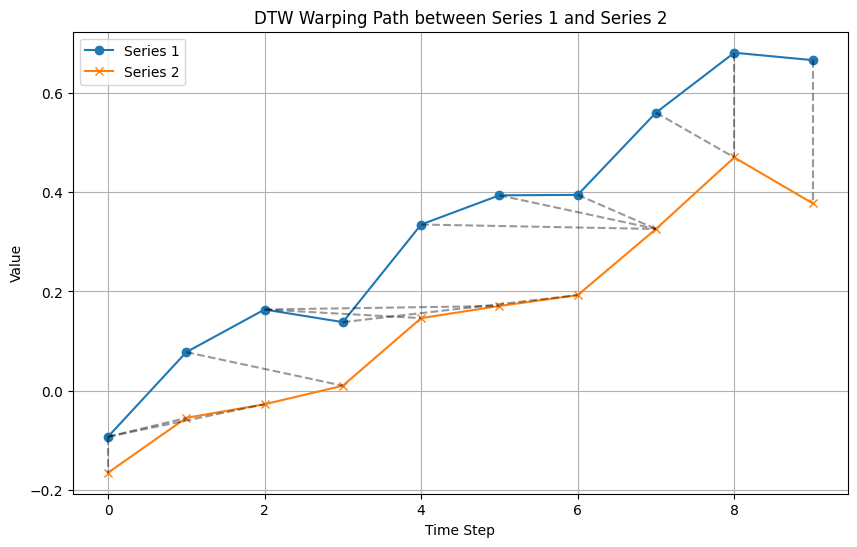

The DTW path demonstrates how points in Series 1 are aligned with points in Series 2 to minimize the cumulative distance. The dashed lines indicate these alignments (warping).


In [39]:
from dtaidistance import dtw

# Select two series from raw_data for DTW visualization
series_idx1 = 0 # Series 1
series_idx2 = 1 # Series 2

ts1 = raw_data[:demo_steps, series_idx1] # Using the first 10 steps of raw_data
ts2 = raw_data[:demo_steps, series_idx2]

# Calculate DTW warping path
path = dtw.warping_path(ts1.astype(float), ts2.astype(float))

# Visualize the two time series and the DTW warping path
plt.figure(figsize=(10, 6))
plt.plot(ts1, label=f'Series {series_idx1 + 1}', marker='o')
plt.plot(ts2, label=f'Series {series_idx2 + 1}', marker='x')

# Plot the warping path
for ts1_idx, ts2_idx in path:
    plt.plot([ts1_idx, ts2_idx], [ts1[ts1_idx], ts2[ts2_idx]], 'k--', alpha=0.4)

plt.title(f'DTW Warping Path between Series {series_idx1 + 1} and Series {series_idx2 + 1}')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

print(f"The DTW path demonstrates how points in Series {series_idx1 + 1} are aligned with points in Series {series_idx2 + 1} to minimize the cumulative distance. The dashed lines indicate these alignments (warping).")

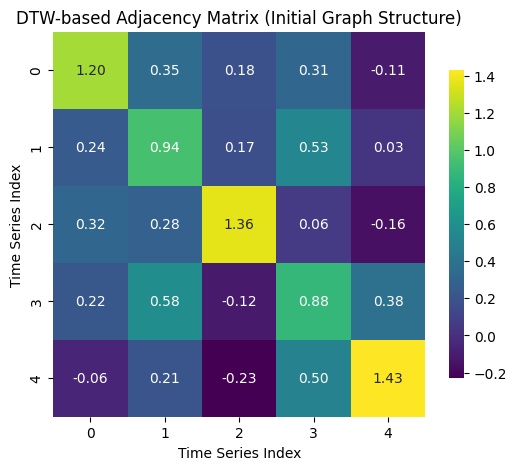

The DTW-based adjacency matrix, as visualized above, forms the initial graph structure for the DTWGCN model. It quantifies the dynamic similarity between each pair of time series, where darker colors indicate higher similarity and thus stronger initial connections in the graph.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(dtw_adj_matrix.cpu().numpy(), annot=True, cmap='viridis', fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('DTW-based Adjacency Matrix (Initial Graph Structure)')
plt.xlabel('Time Series Index')
plt.ylabel('Time Series Index')
plt.show()

print("The DTW-based adjacency matrix, as visualized above, forms the initial graph structure for the DTWGCN model. It quantifies the dynamic similarity between each pair of time series, where darker colors indicate higher similarity and thus stronger initial connections in the graph.")

Calculated sigma for DTW adjacency: 6.1631


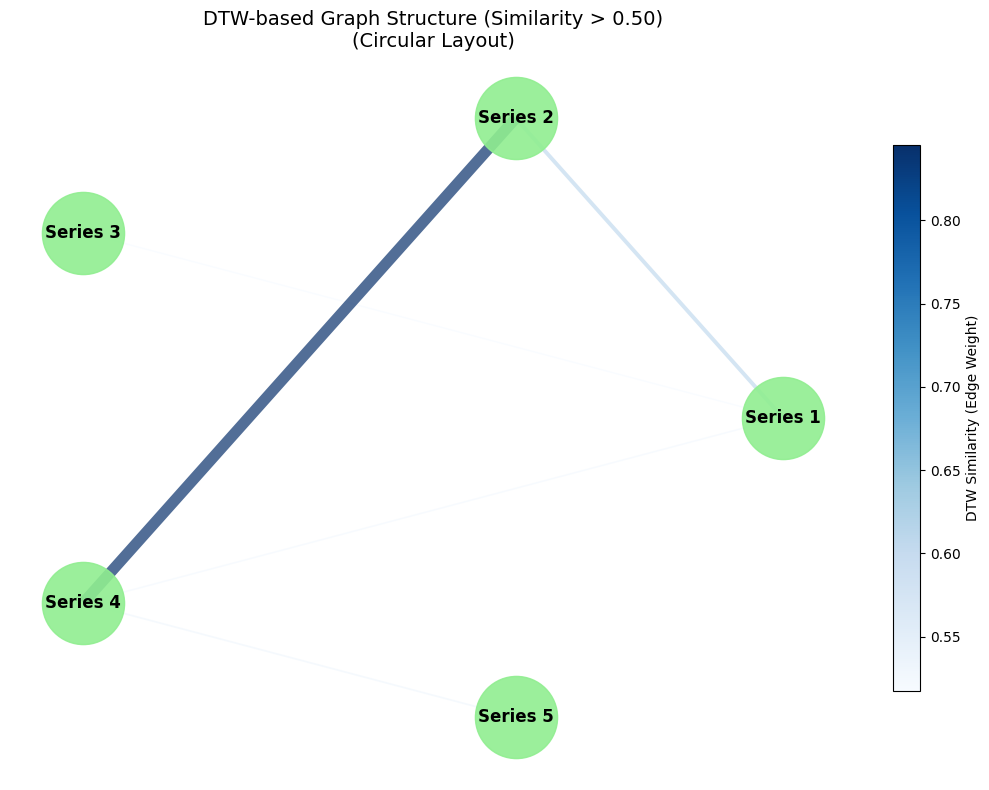

The graph above visualizes the connections between time series based on their Dynamic Time Warping (DTW) similarity using a circular layout. Only connections with a similarity greater than 0.50 are shown. Thicker and darker blue edges indicate stronger similarity.


In [48]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch # Import torch to check if dtw_adj_matrix is a tensor

# Explicitly recalculate the DTW-based adjacency matrix to ensure we use the initial one.
# This prevents any potential overwrites by learned adjacency matrices.
# Assuming 'raw_data' and 'calculate_dtw_adjacency_matrix' are available from previous cells.
plot_dtw_adj_matrix_tensor = calculate_dtw_adjacency_matrix(raw_data, sigma=None)
plot_dtw_adj_np = plot_dtw_adj_matrix_tensor.cpu().numpy()

# Create a NetworkX graph
G_dtw = nx.Graph()

# Add nodes for each time series
N_SERIES = plot_dtw_adj_np.shape[0]
labels = {i: f'Series {i+1}' for i in range(N_SERIES)}
G_dtw.add_nodes_from(labels.keys())

# Add edges based on DTW similarity matrix
# We'll use a threshold to only show significant connections
# You can adjust this threshold based on the distribution of your similarity scores
similarity_threshold = 0.5 # Example threshold for visualization

edges_data = []
for i in range(N_SERIES):
    for j in range(i + 1, N_SERIES): # Avoid self-loops and duplicate edges
        similarity = plot_dtw_adj_np[i, j]
        if similarity > similarity_threshold:
            edges_data.append((i, j, {'weight': similarity}))
            G_dtw.add_edge(i, j, weight=similarity)

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G_dtw) # Changed from spring_layout to circular_layout

# Draw nodes
nx.draw_networkx_nodes(G_dtw, pos, node_color='lightgreen', node_size=3500, alpha=0.9)

# Draw labels for nodes
nx.draw_networkx_labels(G_dtw, pos, labels, font_size=12, font_weight='bold', font_color='black')

# Draw edges with varying thickness and color based on weight
if edges_data:
    edges = G_dtw.edges(data=True)
    weights = [d['weight'] for u, v, d in edges]

    # Scale edge widths for better visualization, e.g., from 1 to 8
    max_weight = max(weights) if weights else 1.0
    min_weight = min(weights) if weights else 0.0

    if max_weight > min_weight:
        # Normalize weights to a more visible range (e.g., 1 to 8)
        scaled_widths = [((w - min_weight) / (max_weight - min_weight)) * 7 + 1 for w in weights]
    else:
        scaled_widths = [2 for _ in weights] # Default width if all weights are identical

    # Use a 'Blues' colormap for intuitive representation of similarity
    # Darker blue means higher similarity
    cmap = plt.cm.Blues
    # Normalize weights to the 0-1 range for the colormap
    norm = plt.Normalize(vmin=min_weight, vmax=max_weight)
    ed_colors = [cmap(norm(w)) for w in weights]

    nx.draw_networkx_edges(G_dtw, pos, edgelist=G_dtw.edges(), width=scaled_widths, edge_color=ed_colors, alpha=0.7)

    # Create a colorbar for edge weights
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(weights)
    cb = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.03, pad=0.04)
    cb.set_label('DTW Similarity (Edge Weight)', fontsize=10)

plt.title(f'DTW-based Graph Structure (Similarity > {similarity_threshold:.2f})\n(Circular Layout)', fontsize=14)
plt.axis('off') # Hide axes
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print(f"The graph above visualizes the connections between time series based on their Dynamic Time Warping (DTW) similarity using a circular layout. Only connections with a similarity greater than {similarity_threshold:.2f} are shown. Thicker and darker blue edges indicate stronger similarity.")